# Gigs Senior Data Analyst Challenge

Welcome to the Gigs data analyst take-home challenge! This notebook will help you get started with analyzing our connectivity usage data.

## About the Data

You'll be working with three main datasets:
- **Usage Data**: Detailed usage per subscription period (~100K+ records)
- **Plan Events**: Plan configuration and pricing history
- **Projects**: Project metadata

## Setup Instructions

Run the cells below to set up your environment and load the data into DuckDB.

In [1]:
# Import required libraries
import duckdb
import pandas as pd
from datetime import datetime, timedelta

print("✅ Libraries imported successfully!")

✅ Libraries imported successfully!


In [2]:
# Load JupySQL extension and configure
%load_ext sql

# Configure JupySQL for better output
%config SqlMagic.autopandas = True
%config SqlMagic.feedback = False
%config SqlMagic.displaycon = False

print("✅ JupySQL configured!")

✅ JupySQL configured!


In [3]:
# Connect to DuckDB
conn = duckdb.connect('gigs-analytics.db')
%sql conn --alias duckdb

print("✅ Connected to DuckDB database: gigs-analytics.db")

✅ Connected to DuckDB database: gigs-analytics.db


In [4]:
%%sql
-- Load data into DuckDB tables
CREATE OR REPLACE TABLE usage_data AS 
SELECT * FROM 'data/usage_by_subscription_period.csv';

CREATE OR REPLACE TABLE plan_events AS 
SELECT * FROM 'data/plan_change_events.csv';

CREATE OR REPLACE TABLE projects AS 
SELECT * FROM 'data/projects.csv';

,Count
0,3


In [5]:
%%sql
-- Verify data loading
select 
  'usage_data' as table_name, 
  count(*) as row_count,
  count(distinct subscription_id) as unique_subscriptions
from usage_data
union all
select 
  'plan_events' as table_name, 
  count(*) as row_count,
  count(distinct plan_id) as unique_plans
from plan_events
union all
select 
  'projects' as table_name, 
  count(*) as row_count,
  count(distinct project_id__hashed) as unique_projects
from projects;

,table_name,row_count,unique_subscriptions
0,usage_data,53565,8457
1,plan_events,209,36
2,projects,3,3


## Your Analysis Starts Here!

Now you have everything set up. Use the cells below to start your analysis.

### Tips:
- Use `%%sql` for multi-line SQL queries
- Use `%sql variable_name <<` to store results in a Python variable
- Combine SQL with Python/Pandas for advanced analysis
- Feel free to use any visualisation library you feel comfortable with

---
---
# Start

#### Additional tools

In [6]:

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import plotly.express as px


# 1) Loading

In [7]:
pro = pd.read_csv('data/projects.csv')
df = pd.read_csv('data/usage_by_subscription_period.csv')
plan = pd.read_csv('data/plan_change_events.csv')

In [8]:
pro.head()

,project_id__hashed,project_type,organization_name,device_type
0,dace2786aee7632e61757b320a6fe5bff37a2e742fe558...,API,People Mobile,Phones
1,82728d5d3cf7f35b58bc318399c2c5caf7eeadcc37f359...,Connect,ACME Phone,Phones
2,2aeca1a6c1ecf52b28b7f7646b6fb90563a417ee3e5dc3...,Connect,SmartDevices Inc.,Wearables


In [9]:
pro.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3 entries, 0 to 2
Data columns (total 4 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   project_id__hashed  3 non-null      object
 1   project_type        3 non-null      object
 2   organization_name   3 non-null      object
 3   device_type         3 non-null      object
dtypes: object(4)
memory usage: 224.0+ bytes


In [10]:
df.head(2)

,subscription_id,project_id__hashed,plan_id,reporting_date,subscription_period_start,subscription_period_end,subscription_period_number,cumulative_data_usage_megabyte,cumulative_voice_usage_minutes,cumulative_sms_usage,number_of_addons_activated
0,sub_b97107a1c7ef89cf28a7e83ee850,82728d5d3cf7f35b58bc318399c2c5caf7eeadcc37f359...,pln_0a3b55b9abb575b023c07e617b49,2024-02-07 00:00:00,2024-02-04,2024-02-07,1,0.000000,0.0,0.0,0
1,sub_2353ef9e8bf55916b97ceb30194c,82728d5d3cf7f35b58bc318399c2c5caf7eeadcc37f359...,pln_0a3b55b9abb575b023c07e617b49,2024-02-08 00:00:00,2024-01-25,2024-02-08,1,56.660992,1.0,1.0,0


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53565 entries, 0 to 53564
Data columns (total 11 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   subscription_id                 53565 non-null  object 
 1   project_id__hashed              53565 non-null  object 
 2   plan_id                         53565 non-null  object 
 3   reporting_date                  53565 non-null  object 
 4   subscription_period_start       53565 non-null  object 
 5   subscription_period_end         53565 non-null  object 
 6   subscription_period_number      53565 non-null  int64  
 7   cumulative_data_usage_megabyte  53565 non-null  float64
 8   cumulative_voice_usage_minutes  53565 non-null  float64
 9   cumulative_sms_usage            53565 non-null  float64
 10  number_of_addons_activated      53565 non-null  int64  
dtypes: float64(3), int64(2), object(6)
memory usage: 4.5+ MB


In [12]:
plan.head(3)


,plan_id,project_id__hashed,plan_created_at,event_type,event_timestamp,plan_name,network_provider_id,price_currency,plan_price_amount_local,data_allowance_mb,is_unlimited_data,voice_allowance_seconds,is_unlimited_voice,sms_allowance,is_unlimited_sms,validity_value,validity_unit,_valid_from,_valid_to,_is_current_state
0,pln_b2a155624e05108d1a5b6b90f567,82728d5d3cf7f35b58bc318399c2c5caf7eeadcc37f359...,2023-12-29 18:43:12,plan.updated,2023-12-29 18:44:37.573698,Unlimited Data Plan,p4,USD,70.0,NaN,True,NaN,True,NaN,True,30,day,2023-12-29 18:44:37.573698,2023-12-29 18:44:37.846803,False
1,pln_b2a155624e05108d1a5b6b90f567,82728d5d3cf7f35b58bc318399c2c5caf7eeadcc37f359...,2023-12-29 18:43:12,plan.archived,2024-01-21 15:48:13.444971,Unlimited Data Plan,p4,USD,70.0,NaN,True,NaN,True,NaN,True,30,day,2024-01-21 15:48:13.444971,NaN,True
2,pln_b2a155624e05108d1a5b6b90f567,82728d5d3cf7f35b58bc318399c2c5caf7eeadcc37f359...,2023-12-29 18:43:12,plan.updated,2024-01-21 15:48:12.953812,Unlimited Data Plan,p4,USD,70.0,NaN,True,NaN,True,NaN,True,30,day,2024-01-21 15:48:12.953812,2024-01-21 15:48:13.444971,False


In [13]:
plan.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 209 entries, 0 to 208
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   plan_id                  209 non-null    object 
 1   project_id__hashed       209 non-null    object 
 2   plan_created_at          209 non-null    object 
 3   event_type               209 non-null    object 
 4   event_timestamp          209 non-null    object 
 5   plan_name                209 non-null    object 
 6   network_provider_id      209 non-null    object 
 7   price_currency           209 non-null    object 
 8   plan_price_amount_local  209 non-null    float64
 9   data_allowance_mb        120 non-null    float64
 10  is_unlimited_data        209 non-null    bool   
 11  voice_allowance_seconds  41 non-null     float64
 12  is_unlimited_voice       209 non-null    bool   
 13  sms_allowance            35 non-null     float64
 14  is_unlimited_sms         2

In [14]:
plan.duplicated().all(), df.duplicated().all() , pro.duplicated().all()

(np.False_, np.False_, np.False_)

# 2) DATA QUALITY CHECKS



In [15]:
def show_stats(df):
    for cols in df.columns:
        print(f"{cols} {'-'*(20-len(cols))}:  unique[{df[cols].nunique()}], null: {df[cols].isnull().sum()}, na:{df[cols].isna().sum()} \n samples --> {df[cols].unique()[:3]}", end="\n\n")

print('-----------------------------------------')
print('---------------- project ----------------')
print('-----------------------------------------\n\n')
show_stats(pro)
print('-----------------------------------------')
print('-----------------subscriptions-----------')
print('-----------------------------------------\n\n')
show_stats(df)
print('----------------------------------------------')
print('-----------------plan_change_events-----------')
print('----------------------------------------------\n\n')
show_stats(plan)



-----------------------------------------
---------------- project ----------------
-----------------------------------------


project_id__hashed --:  unique[3], null: 0, na:0 
 samples --> ['dace2786aee7632e61757b320a6fe5bff37a2e742fe5582c245665e3d0e3a84e'
 '82728d5d3cf7f35b58bc318399c2c5caf7eeadcc37f3597cb2817a9b5a87bbf3'
 '2aeca1a6c1ecf52b28b7f7646b6fb90563a417ee3e5dc32f9d1a50d7e8b9e13a']

project_type --------:  unique[2], null: 0, na:0 
 samples --> ['API' 'Connect']

organization_name ---:  unique[3], null: 0, na:0 
 samples --> ['People Mobile' 'ACME Phone' 'SmartDevices Inc.']

device_type ---------:  unique[2], null: 0, na:0 
 samples --> ['Phones' 'Wearables']

-----------------------------------------
-----------------subscriptions-----------
-----------------------------------------


subscription_id -----:  unique[8457], null: 0, na:0 
 samples --> ['sub_b97107a1c7ef89cf28a7e83ee850' 'sub_2353ef9e8bf55916b97ceb30194c'
 'sub_5d5605c8cf0b46116a42cedb9561']

project_id__hash

In [16]:
plan.event_type.unique()

array(['plan.updated', 'plan.archived', 'plan.published', 'plan.created'],
      dtype=object)

## Observations:

In general:

- There are no null values (except and sms allowance , which are not being used)
- There are no duplicates

Project: 

1. Its clean

Subscription: 

1. subscription start and end have different lenght, to check why.
1. cumulative data usage can be 0 
1. same for sms
  
Plan: 
1. voice_allowance_seconds , sms_allowance  could need some cleaning, but here we wont use it
1. plan archived could be use for churn
1. There are plan prices  that are 0 usd



In [17]:
%%sql

# can a subscription have multiple plans? - YES

SELECT 
subscription_id
# count(Distinct plan_id) as total_plans
FROM usage_data
# group by 1
# order by 2 desc 
limit 2; 

,subscription_id
0,sub_b97107a1c7ef89cf28a7e83ee850
1,sub_2353ef9e8bf55916b97ceb30194c


In [18]:
%%sql

# example of a subscription with multiple plans
select 
* 
from usage_data

where subscription_id = 'sub_bf65d729c2df4092017eaea0ee0a';



,subscription_id,project_id__hashed,plan_id,reporting_date,subscription_period_start,subscription_period_end,subscription_period_number,cumulative_data_usage_megabyte,cumulative_voice_usage_minutes,cumulative_sms_usage,number_of_addons_activated
0,sub_bf65d729c2df4092017eaea0ee0a,82728d5d3cf7f35b58bc318399c2c5caf7eeadcc37f359...,pln_0a3b55b9abb575b023c07e617b49,2024-05-24,2024-04-25,2024-05-25,1,1829.331968,773.0,214.0,0
1,sub_bf65d729c2df4092017eaea0ee0a,82728d5d3cf7f35b58bc318399c2c5caf7eeadcc37f359...,pln_0a3b55b9abb575b023c07e617b49,2024-06-24,2024-05-25,2024-06-25,2,1488.722944,1761.0,484.0,0
2,sub_bf65d729c2df4092017eaea0ee0a,82728d5d3cf7f35b58bc318399c2c5caf7eeadcc37f359...,pln_0a3b55b9abb575b023c07e617b49,2024-07-24,2024-06-25,2024-07-25,3,1360.831488,1695.0,1205.0,0
3,sub_bf65d729c2df4092017eaea0ee0a,82728d5d3cf7f35b58bc318399c2c5caf7eeadcc37f359...,pln_0a3b55b9abb575b023c07e617b49,2024-08-24,2024-07-25,2024-08-25,4,1040.356352,1370.0,340.0,0
4,sub_bf65d729c2df4092017eaea0ee0a,82728d5d3cf7f35b58bc318399c2c5caf7eeadcc37f359...,pln_0a3b55b9abb575b023c07e617b49,2024-09-24,2024-08-25,2024-09-25,5,1449.269248,1179.0,243.0,0
5,sub_bf65d729c2df4092017eaea0ee0a,82728d5d3cf7f35b58bc318399c2c5caf7eeadcc37f359...,pln_0a3b55b9abb575b023c07e617b49,2024-10-24,2024-09-25,2024-10-25,6,1337.875456,1093.0,289.0,0
6,sub_bf65d729c2df4092017eaea0ee0a,82728d5d3cf7f35b58bc318399c2c5caf7eeadcc37f359...,pln_0a3b55b9abb575b023c07e617b49,2024-11-24,2024-10-25,2024-11-25,7,1284.484096,1306.0,443.0,0
7,sub_bf65d729c2df4092017eaea0ee0a,82728d5d3cf7f35b58bc318399c2c5caf7eeadcc37f359...,pln_af7b4a30086929d37e7f4eb3daed,2024-12-24,2024-11-25,2024-12-25,8,9843.621888,1300.0,553.0,0
8,sub_bf65d729c2df4092017eaea0ee0a,82728d5d3cf7f35b58bc318399c2c5caf7eeadcc37f359...,pln_1d3f49d61a672755efc1865c4d9a,2025-01-24,2024-12-25,2025-01-25,9,13642.873856,1021.0,229.0,0
9,sub_bf65d729c2df4092017eaea0ee0a,82728d5d3cf7f35b58bc318399c2c5caf7eeadcc37f359...,pln_1d3f49d61a672755efc1865c4d9a,2025-02-24,2025-01-25,2025-02-25,10,19221.571584,706.0,188.0,0


In [19]:
%%sql

# testing if overlapping periods are possible- YES

select 
subscription_id,
max(subscription_period_number) as max_subscription_period_number,
count(distinct subscription_period_number) as total_subscription_period_number
from usage_data
group by 1
having max_subscription_period_number != total_subscription_period_number;

,subscription_id,max_subscription_period_number,total_subscription_period_number
0,sub_dbf0da1db52d6ca0b0b593586f48,14,8
1,sub_994618eefe4414351f35ce447846,10,8
2,sub_9f71a35b13b5c13a52085c160b7b,5,2
3,sub_d1638d78fca83bce17aa8492e485,10,7
4,sub_1248c9c61b1e550c500764dfa62d,3,2
...,...,...,...
125,sub_01c7593ff53bcf2e90678637e0cd,3,2
126,sub_b2aaaa8ae16e8e5493e2d7317103,5,4
127,sub_552e85f62a1fb73905fe369df752,7,5
128,sub_a86663275ca75dd240589046e1cc,12,7


In [20]:
%%sql 

# -- there are overlapping period_numbers  as well as missing periods 

select 
* 
from usage_data

where subscription_id = 'sub_b05686892dcc5e429cde4571596c';





,subscription_id,project_id__hashed,plan_id,reporting_date,subscription_period_start,subscription_period_end,subscription_period_number,cumulative_data_usage_megabyte,cumulative_voice_usage_minutes,cumulative_sms_usage,number_of_addons_activated
0,sub_b05686892dcc5e429cde4571596c,82728d5d3cf7f35b58bc318399c2c5caf7eeadcc37f359...,pln_0a3b55b9abb575b023c07e617b49,2024-03-29,2024-02-29,2024-03-30,1,342.447104,144.0,172.0,0
1,sub_b05686892dcc5e429cde4571596c,82728d5d3cf7f35b58bc318399c2c5caf7eeadcc37f359...,pln_0a3b55b9abb575b023c07e617b49,2024-05-30,2024-04-30,2024-05-30,3,0.000000,0.0,0.0,0
2,sub_b05686892dcc5e429cde4571596c,82728d5d3cf7f35b58bc318399c2c5caf7eeadcc37f359...,pln_0a3b55b9abb575b023c07e617b49,2024-08-29,2024-07-31,2024-08-29,6,0.000000,0.0,0.0,0
3,sub_b05686892dcc5e429cde4571596c,82728d5d3cf7f35b58bc318399c2c5caf7eeadcc37f359...,pln_0a3b55b9abb575b023c07e617b49,2024-09-30,2024-08-29,2024-09-30,7,0.000000,0.0,0.0,0
4,sub_b05686892dcc5e429cde4571596c,82728d5d3cf7f35b58bc318399c2c5caf7eeadcc37f359...,pln_0a3b55b9abb575b023c07e617b49,2024-10-21,2024-09-30,2024-10-21,7,0.000000,0.0,0.0,0


In [21]:

%%sql
# can a subscription have multiple projects? - NO

SELECT 
subscription_id,
count(distinct project_id__hashed) as total_projects
FROM usage_data
group by 1

order by 2 desc 
limit 3; 

,subscription_id,total_projects
0,sub_b56b0fcd9efd8272b30db23acbbe,1
1,sub_099bb14eb4de4220caff588285a5,1
2,sub_1afda13b49ea838a2da9e4db4c47,1


# 3) Solving the Questions:

## Q1 : How much data does a subscription typically consume?


Thoughts:
  
This questions is vague thus it depends by the perspective. Unfortunatelly we dont know which team is asking this question (finance, customer service, ...)

TO DO:  
  1. First lets find the data consumption 
  1. Join with the plan using plan_id and project to have all dimensions
  1. Filter to finished/ended subscriptions to avoid ongoing subscriptions
  1. Because there are gaps in the period progression AND repited numbers, use count.  
  1. There could be empty usage months, thus we take out from the calculation
  1. There could be many dimensions to calculate the avg, such as  per project, per plan, device, etc. but since is not explicitly asked we take the globla view.
  1. A subscription could have several plans, for simplicity we will only use subscriptions that have finished all plans.
    
  

In [22]:
%%sql

WITH 

valid_subscriptions AS (

  SELECT 
    subscription_id,
    MAX(reporting_date) as latest_report,
    MAX(subscription_period_end) as last_period_end_date
  FROM
    usage_data
  GROUP BY 
    subscription_id
  HAVING
     MAX(reporting_date) >= MAX(subscription_period_end) 
),

subscription_usage AS (
  
  SELECT 
    a.project_id__hashed,
    a.subscription_id,
    COUNT(a.subscription_period_number) AS count_periods,
    SUM(a.cumulative_data_usage_megabyte) AS sum_data_usage,
    SUM(a.cumulative_data_usage_megabyte) / COUNT(a.subscription_period_number) as avg_usage
  FROM 
    usage_data as a
  INNER JOIN 
    valid_subscriptions as b
    on a.subscription_id = b.subscription_id
  
    
  GROUP BY 1,2
  HAVING sum_data_usage > 0 
  
)
  
  
SELECT 
 sum(sum_data_usage)/sum(count_periods) global_avg,
 median(avg_usage) as median_avg, 
 min(avg_usage) as min_usage,
 max(avg_usage) as max_usage,
 PERCENTILE_CONT(0.25) WITHIN GROUP( ORDER BY sum_data_usage) as p25_usage,
 PERCENTILE_CONT(0.50) WITHIN GROUP( ORDER BY sum_data_usage) as p50_usage,
 PERCENTILE_CONT(0.75) WITHIN GROUP( ORDER BY sum_data_usage) as p75_usage,
 PERCENTILE_CONT(0.80) WITHIN GROUP( ORDER BY sum_data_usage) as p80_usage,
 PERCENTILE_CONT(0.95) WITHIN GROUP( ORDER BY sum_data_usage) as p95_usage,
 COUNT(subscription_id) as count_subscriptions

FROM
  subscription_usage



,global_avg,median_avg,min_usage,max_usage,p25_usage,p50_usage,p75_usage,p80_usage,p95_usage,count_subscriptions
0,2127.970248,297.99936,0.001024,211464.075264,257.219654,1295.480832,4842.07104,6846.686003,40173.273907,1695


In [23]:
#translation to pandas  for graph
valid_subscriptions = (
    df.groupby('subscription_id')
    .agg(
        latest_report=('reporting_date', 'max'),
        last_period_end_date=('subscription_period_end', 'max')
    )
    .query('latest_report >= last_period_end_date')
    .reset_index()
)
 
merged = df.merge(
    valid_subscriptions[['subscription_id']],
    on='subscription_id',
    how='inner'
)
 
subscription_usage = (
    merged.groupby(['project_id__hashed', 'subscription_id'])
    .agg(
        count_periods=('subscription_period_number', 'count'),
        sum_data_usage=('cumulative_data_usage_megabyte', 'sum')
    )
    .assign(avg_usage=lambda x: x['sum_data_usage'] / x['count_periods'])
    .query('sum_data_usage > 0')
    .reset_index()
)

# Result
subscription_usage.head(3)


,project_id__hashed,subscription_id,count_periods,sum_data_usage,avg_usage
0,2aeca1a6c1ecf52b28b7f7646b6fb90563a417ee3e5dc3...,sub_015203778f8164e39eb6da14b60d,1,2036.243082,2036.243082
1,2aeca1a6c1ecf52b28b7f7646b6fb90563a417ee3e5dc3...,sub_02490d144652ff8ecd5b00f5f5dd,3,5924.890858,1974.963619
2,2aeca1a6c1ecf52b28b7f7646b6fb90563a417ee3e5dc3...,sub_0340ff7f0023a5200678fe06f9d1,1,0.343415,0.343415


In [24]:
subscription_usage.describe()

,count_periods,sum_data_usage,avg_usage
count,1695.000000,1.695000e+03,1695.000000
mean,4.800000,1.021426e+04,2640.936534
std,3.600898,4.494956e+04,10640.580260
min,1.000000,1.024000e-03,0.001024
25%,2.000000,2.572197e+02,96.603648
50%,3.000000,1.295481e+03,297.999360
75%,7.000000,4.842071e+03,1073.108146
max,15.000000,1.094672e+06,211464.075264


(array([642., 225., 135., ...,   0.,   0.,   1.]),
 array([1.02400000e-03, 1.63799687e+02, 3.27598350e+02, ...,
        2.11136478e+05, 2.11300277e+05, 2.11464075e+05]),
 <BarContainer object of 1291 artists>)

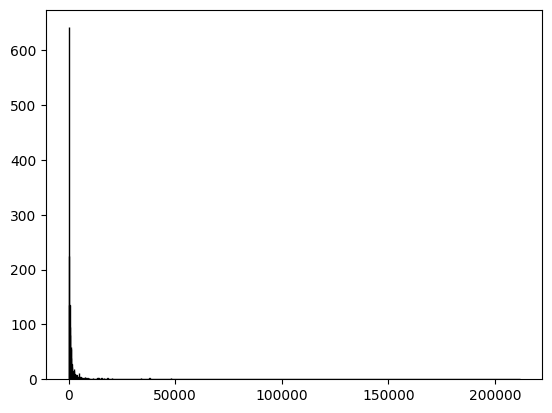

In [25]:
plt.hist(subscription_usage['avg_usage'], bins='auto', edgecolor='black')

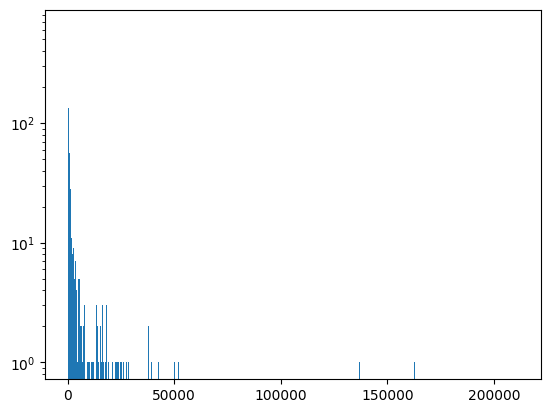

In [26]:
plt.hist(subscription_usage['avg_usage'], bins='auto')
plt.yscale('log') 

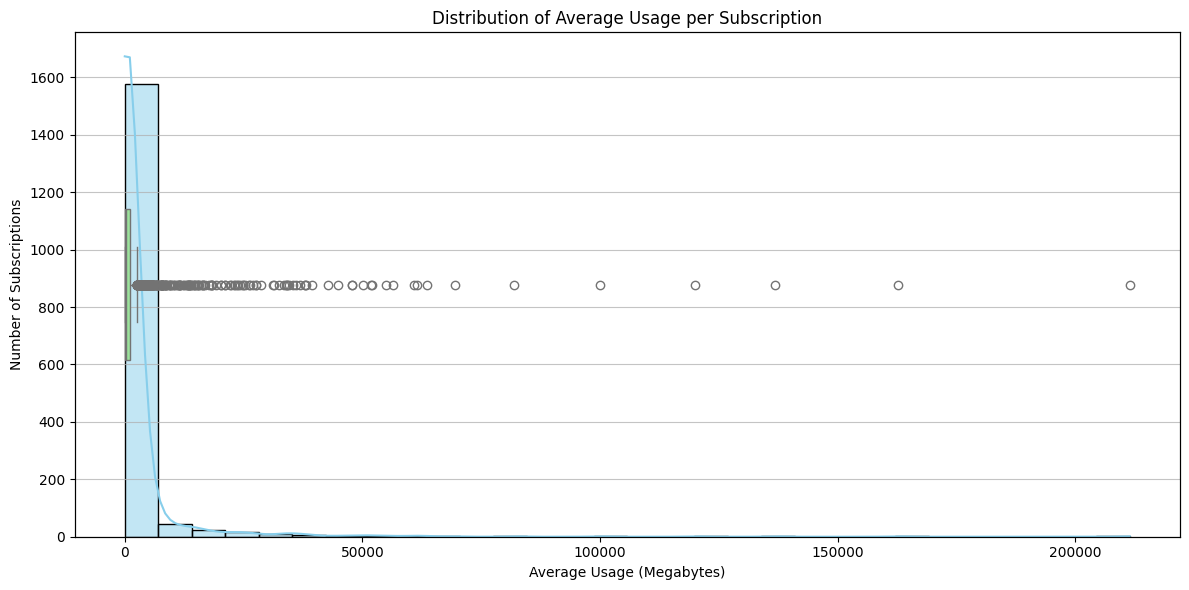

In [27]:
plt.figure(figsize=(12, 6))

# Histogram with KDE
ax1 = plt.subplot(1, 1, 1)
sns.histplot(subscription_usage['avg_usage'], bins=30, kde=True, color='skyblue', edgecolor='black', ax=ax1)
ax1.set_title('Distribution of Average Usage per Subscription')
ax1.set_xlabel('Average Usage (Megabytes)')
ax1.set_ylabel('Number of Subscriptions')
ax1.grid(axis='y', alpha=0.75)

# Horizontal box plot (on a separate y-axis)
ax2 = ax1.twinx()
sns.boxplot(x=subscription_usage['avg_usage'], orient='h', color='lightgreen', width=0.3, ax=ax2)
ax2.set_yticks([])
ax2.set_xlabel('')

plt.tight_layout()
plt.show()

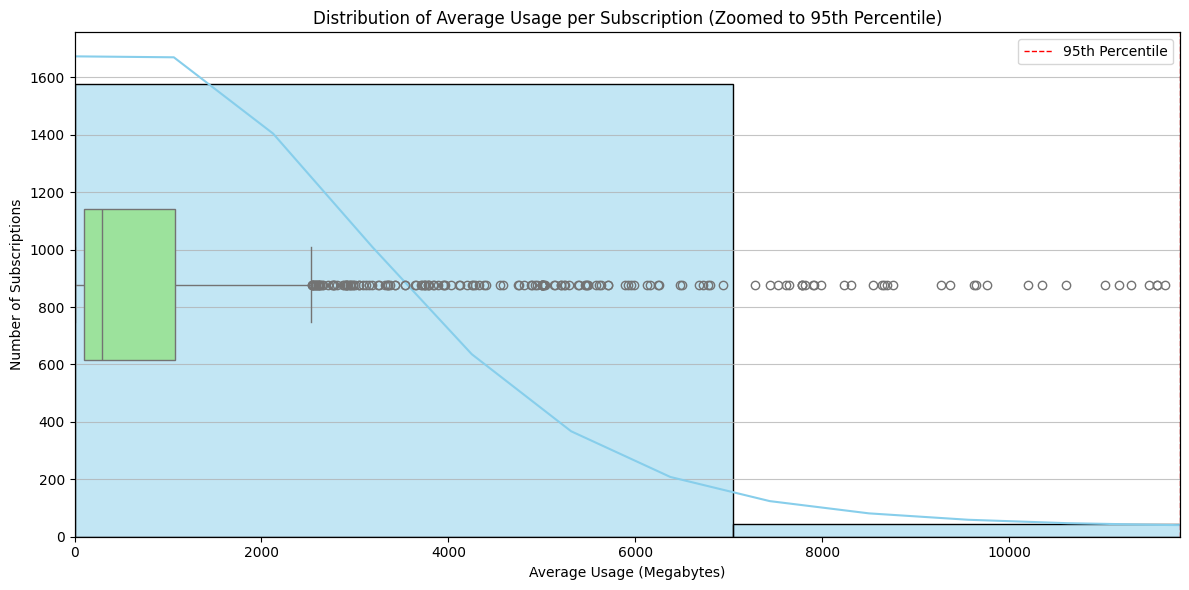

In [28]:
import numpy as np

# Calculate the 95th percentile
percentile_95 = np.percentile(subscription_usage['avg_usage'], 95)

# Create the figure and axes
plt.figure(figsize=(12, 6))

# Histogram with KDE
ax1 = plt.subplot(1, 1, 1)
sns.histplot(subscription_usage['avg_usage'], bins=30, kde=True, color='skyblue', edgecolor='black', ax=ax1)
ax1.set_title('Distribution of Average Usage per Subscription (Zoomed to 95th Percentile)')
ax1.set_xlabel('Average Usage (Megabytes)')
ax1.set_ylabel('Number of Subscriptions')
ax1.grid(axis='y', alpha=0.75)
ax1.set_xlim(0, percentile_95)  # Zoom to 95th percentile

# Horizontal box plot (on a separate y-axis)
ax2 = ax1.twinx()
sns.boxplot(x=subscription_usage['avg_usage'], orient='h', color='lightgreen', width=0.3, ax=ax2)
ax2.set_yticks([])
ax2.set_xlim(0, percentile_95)  # Match the zoom
ax2.set_xlabel('')

# Optionally, add a vertical line at the 95th percentile
ax1.axvline(percentile_95, color='red', linestyle='--', linewidth=1, label='95th Percentile')
ax1.legend()

plt.tight_layout()
plt.show()


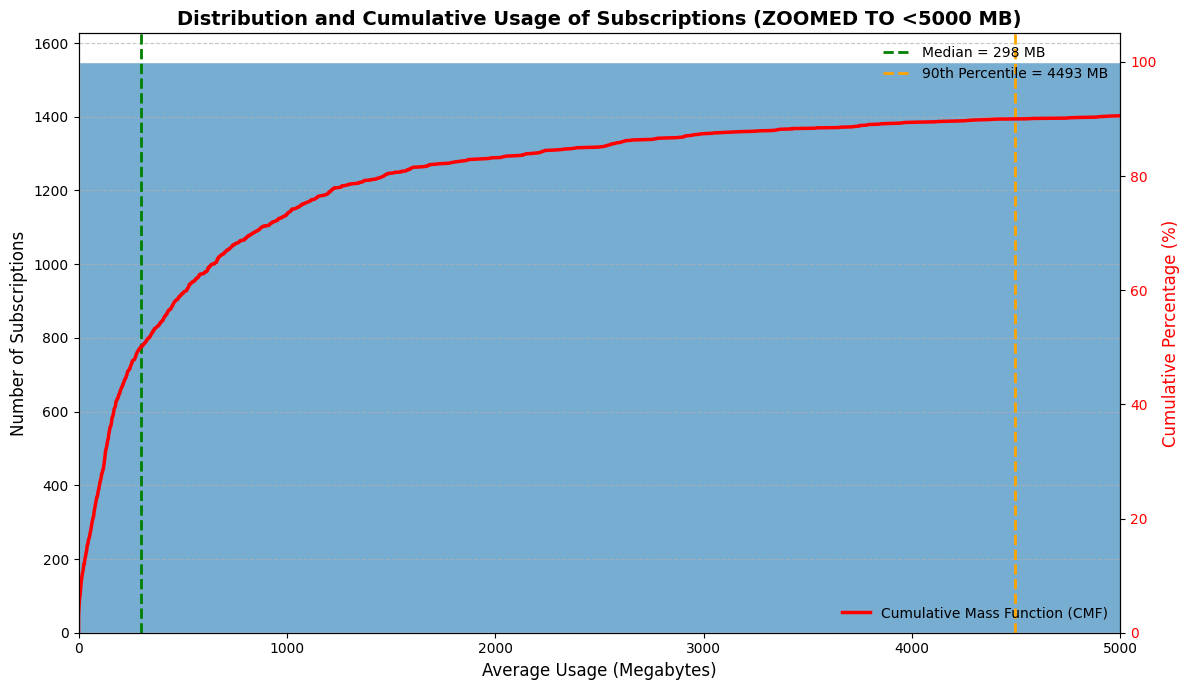

In [29]:
plt.figure(figsize=(12, 7))

# Sort and compute CMF
data = subscription_usage['avg_usage'].dropna()
sorted_usage = np.sort(data)
cmf = np.arange(1, len(sorted_usage) + 1) / len(sorted_usage) * 100

# Create main histogram with KDE
ax1 = sns.histplot(
    data,
    bins=40, 
    edgecolor='white',
    alpha=0.6
)
ax1.set_xlim(0, 5000)
ax1.set_xlabel('Average Usage (Megabytes)', fontsize=12)
ax1.set_ylabel('Number of Subscriptions', fontsize=12)
ax1.set_title('Distribution and Cumulative Usage of Subscriptions (ZOOMED TO <5000 MB)', fontsize=14, weight='bold')
ax1.grid(axis='y', linestyle='--', alpha=0.7)

# Add CMF (secondary y-axis)
ax2 = ax1.twinx()
ax2.plot(sorted_usage, cmf, color='red', linewidth=2.5, label='Cumulative Mass Function (CMF)')
ax2.set_xlim(0, 5000)
ax2.set_ylim(0, 105)
ax2.set_ylabel('Cumulative Percentage (%)', color='red', fontsize=12)
ax2.tick_params(axis='y', labelcolor='red')
ax2.legend(loc='lower right', frameon=False)

# Add median and percentile markers
median_val = np.median(data)
p90_val = np.percentile(data, 90)
ax1.axvline(median_val, color='green', linestyle='--', linewidth=2, label=f'Median = {median_val:.0f} MB')
ax1.axvline(p90_val, color='orange', linestyle='--', linewidth=2, label=f'90th Percentile = {p90_val:.0f} MB')
ax1.legend(loc='upper right', frameon=False)

plt.tight_layout()
plt.show()


### ANSWER:

Short Answer: The median consumption is around 298 mb

Long Answer:
 The median and average are far appart showing that there are many outliers and a lot of subscriptions that havent done much consumption. 
 You take a big chunk of subscriptions usage if it lies less than ~1000mb  (easy to remember)
 

---

## Q2:  How does usage look like at different plan data allowances?

In [30]:
plan.groupby(['plan_name','data_allowance_mb']).size()

plan_name           data_allowance_mb
5GB                 5000.0               20
5GB Plan            5000.0               27
5GB Test Plan       5000.0                2
Basic Plan          5000.0                4
Easy Plan           1000.0               13
No Allowances Plan  0.0                  31
Plus Plan           5000.0               13
SMS Only Plan       0.0                  10
dtype: int64

> Here we do filter by plan

In [31]:
%%sql
SELECT
    plan_name,
    network_provider_id,
    is_unlimited_data,
    voice_allowance_seconds,
    is_unlimited_voice,
    sms_allowance,
    is_unlimited_sms,
    COUNT(*) AS count
FROM
    plan
GROUP BY
    plan_name,
    network_provider_id,
    is_unlimited_data,
    voice_allowance_seconds,
    is_unlimited_voice,
    sms_allowance,
    is_unlimited_sms
ORDER BY
    count DESC;

,plan_name,network_provider_id,is_unlimited_data,voice_allowance_seconds,is_unlimited_voice,sms_allowance,is_unlimited_sms,count
0,Ultra Unlimited,p11,True,NaN,True,NaN,True,33
1,No Allowances Plan,p11,False,0.0,False,0.0,False,31
2,Unlimited Plan,p11,True,NaN,True,NaN,True,30
3,5GB Plan,p11,False,NaN,True,NaN,True,27
4,5GB,p11,False,NaN,True,NaN,True,20
5,Unlimited Plan,p13,True,NaN,True,NaN,True,11
6,Unlimited Data Plan,p9,True,NaN,True,NaN,True,9
7,Easy Plan,p9,False,NaN,True,NaN,True,8
8,Plus Plan,p9,False,NaN,True,NaN,True,8
9,SMS Only Plan,p11,False,0.0,False,NaN,True,6


In [32]:
%%sql

WITH 

valid_subscriptions AS (

  SELECT 
    subscription_id,
    plan_id,
    MAX(reporting_date) as latest_report,
    MAX(subscription_period_end) as last_period_end_date
  FROM
    usage_data
  GROUP BY 
    1,2
  HAVING
    MAX(reporting_date) >= MAX(subscription_period_end) 
),

subscription_usage AS (
  
  SELECT 
   
    c.plan_name,
    a.plan_id,
    a.subscription_id,
    COUNT(a.subscription_period_number) AS count_periods,
    SUM(a.cumulative_data_usage_megabyte) AS sum_data_usage,
    SUM(a.cumulative_data_usage_megabyte) / COUNT(a.subscription_period_number) as avg_usage
  FROM 
    usage_data as a
  INNER JOIN 
    valid_subscriptions as b
    on a.subscription_id = b.subscription_id
    
  INNER JOIN 
    plan_events as c
    on a.plan_id = c.plan_id
    AND a.project_id__hashed = c.project_id__hashed
    
  GROUP BY 1,2,3
  HAVING sum_data_usage > 0 
  
)

  
SELECT 
 -- dimnensions
 plan_name,
 
 -- calcuations
 sum(sum_data_usage)/sum(count_periods) global_avg,
 median(avg_usage) as median_avg, 
 min(avg_usage) as min_usage,
 max(avg_usage) as max_usage,
 PERCENTILE_CONT(0.25) WITHIN GROUP( ORDER BY sum_data_usage) as p25_usage,
 PERCENTILE_CONT(0.50) WITHIN GROUP( ORDER BY sum_data_usage) as p50_usage,
 PERCENTILE_CONT(0.75) WITHIN GROUP( ORDER BY sum_data_usage) as p75_usage,
 PERCENTILE_CONT(0.80) WITHIN GROUP( ORDER BY sum_data_usage) as p80_usage,
 PERCENTILE_CONT(0.95) WITHIN GROUP( ORDER BY sum_data_usage) as p95_usage,
 COUNT(subscription_id) as count_subscriptions

FROM
  subscription_usage
GROUP BY 
  plan_name

,plan_name,global_avg,median_avg,min_usage,max_usage,p25_usage,p50_usage,p75_usage,p80_usage,p95_usage,count_subscriptions
0,5GB,1976.239699,248.346624,0.002048,5201.029120,13.254656,1855.954944,20001.165312,20001.956659,2.008792e+04,29
1,Plus Plan,1858.494268,593.215019,0.001303,14385.092096,3472.685056,16546.435072,97133.254656,114294.040166,2.285155e+05,124
2,No Allowances Plan,3805.242807,285.060096,0.171008,80762.446848,322.329600,1425.300480,10960.028160,14942.136320,6.824403e+04,56
3,Basic Plan,767.504417,392.320095,8.874301,5003.660809,587.942140,1603.785264,5341.127999,5987.478345,2.004379e+04,52
4,Ultra Unlimited,30612.121876,16012.318720,0.001024,211464.075264,26358.499840,86381.890560,249603.556864,276636.050432,5.959784e+05,99
5,Easy Plan,517.451787,212.598443,0.002731,14790.416486,1945.976832,8691.580928,24763.432960,31488.457114,8.850399e+04,1217
6,Unlimited Data Plan,13340.732768,4329.544704,0.068480,167558.815488,12181.916160,132935.344128,577864.452096,769160.116224,2.507392e+06,151
7,Unlimited Plan,1573.015258,617.584440,0.000120,22151.625353,597.439592,4044.557377,13175.934047,15194.709598,5.230277e+04,127


In [33]:
valid_subscriptions = (
    df.groupby(['subscription_id', 'plan_id'])
    .agg(
        latest_report=('reporting_date', 'max'),
        last_period_end_date=('subscription_period_end', 'max')
    )
    .query('latest_report >= last_period_end_date')
    .reset_index()
)
 
subscription_usage = (
    df.merge(
        valid_subscriptions[['subscription_id', 'plan_id']],
        on=['subscription_id', 'plan_id'],
        how='inner'
    )
    .merge(
        plan,
        on=['plan_id', 'project_id__hashed'],
        how='inner'
    )
    .groupby(['plan_name', 'plan_id', 'subscription_id'])
    .agg(
        count_periods=('subscription_period_number', 'count'),
        sum_data_usage=('cumulative_data_usage_megabyte', 'sum')
    )
    .assign(avg_usage=lambda x: x['sum_data_usage'] / x['count_periods'])
    .query('sum_data_usage > 0')
    .reset_index()
)
 
result = (
    subscription_usage
    .groupby('plan_name')
    .agg(
        global_avg=('avg_usage', 'mean'),
        median_avg=('avg_usage', 'median'),
        min_usage=('avg_usage', 'min'),
        max_usage=('avg_usage', 'max'),
        p25_usage=('sum_data_usage', lambda x: np.percentile(x, 25)),
        p50_usage=('sum_data_usage', lambda x: np.percentile(x, 50)),
        p75_usage=('sum_data_usage', lambda x: np.percentile(x, 75)),
        p80_usage=('sum_data_usage', lambda x: np.percentile(x, 80)),
        p95_usage=('sum_data_usage', lambda x: np.percentile(x, 95)),
        count_subscriptions=('subscription_id', 'count'), 
    )
    .reset_index()
)

result

,plan_name,global_avg,median_avg,min_usage,max_usage,p25_usage,p50_usage,p75_usage,p80_usage,p95_usage,count_subscriptions
0,5GB,1612.308079,140.163072,0.002048,5201.029120,0.821248,560.652288,17708.820480,19822.327398,2.010476e+04,23
1,Basic Plan,702.605687,391.919274,8.874301,5003.660809,586.212220,1570.883668,5384.525622,6012.633220,2.004703e+04,51
2,Easy Plan,476.184367,200.119751,0.002731,14790.416486,1856.593920,8372.625408,23272.022016,29772.718080,8.649789e+04,1181
3,No Allowances Plan,3805.242807,285.060096,0.171008,80762.446848,322.329600,1425.300480,10960.028160,14942.136320,6.824403e+04,56
4,Plus Plan,1585.739442,561.293380,0.001303,6798.926336,2772.746240,15739.650048,75927.808000,102821.576704,1.961020e+05,106
5,Ultra Unlimited,18563.275059,4843.911168,0.001024,211464.075264,625.916160,27573.348864,104544.871680,119305.223168,4.156787e+05,40
6,Unlimited Data Plan,10555.428806,4402.848768,0.068480,136834.029824,12594.341376,140669.816832,591356.030976,796621.112525,2.555241e+06,127
7,Unlimited Plan,1732.359360,484.865046,0.000120,22151.625353,352.183174,2525.933928,11700.714032,12755.999990,3.691407e+04,89


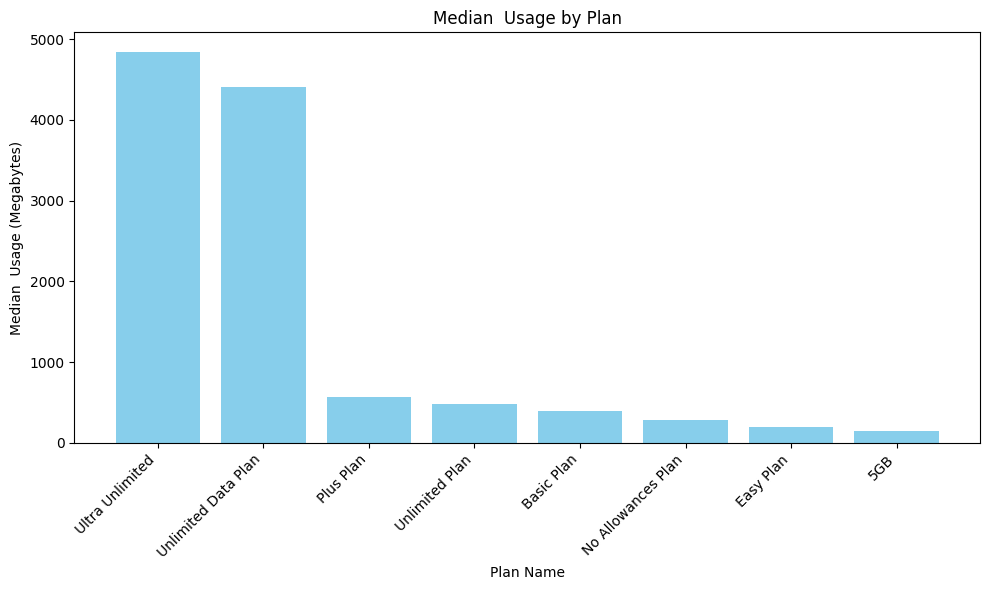

In [34]:

# Sort by median_avg for better visualization (optional)
result_sorted = result.sort_values('median_avg', ascending=False)

# Create the bar plot
plt.figure(figsize=(10, 6))
plt.bar(result_sorted['plan_name'], result_sorted['median_avg'], color='skyblue')

# Add labels and title
plt.title('Median  Usage by Plan')
plt.xlabel('Plan Name')
plt.ylabel('Median  Usage (Megabytes)')
plt.xticks(rotation=45, ha='right')  # Rotate x-labels for readability
plt.tight_layout()  # Adjust layout to prevent label cutoff
plt.show()

> There is a noticeable difference in usage with unlimited data. Lets dig a bit more

In [35]:


valid_subscriptions = (
    df.groupby(['subscription_id', 'plan_id'], as_index=False)
    .agg(
        latest_report=('reporting_date', 'max'),
        last_period_end_date=('subscription_period_end', 'max')
    )
)

valid_subscriptions = valid_subscriptions[
    valid_subscriptions['latest_report'] >= valid_subscriptions['last_period_end_date']
]

subscription_usage = (
    df.merge(valid_subscriptions, on=['subscription_id', 'plan_id'], how='inner')
      .merge(plan, on=['plan_id', 'project_id__hashed'], how='inner')
)

subscription_usage = (
    subscription_usage.groupby(['plan_name', 'plan_id', 'subscription_id', 'network_provider_id'], as_index=False)
    .agg(
        count_periods=('subscription_period_number', 'count'),
        sum_data_usage=('cumulative_data_usage_megabyte', 'sum')
    )
)
 
subscription_usage['avg_usage'] = (
    subscription_usage['sum_data_usage'] / subscription_usage['count_periods']
)
 
subscription_usage = subscription_usage[subscription_usage['sum_data_usage'] > 0]
 
def percentile(x, q):
    return np.percentile(x, q)

summary = (
    subscription_usage.groupby(['plan_name', 'network_provider_id'], as_index=False)
    .agg(
        global_avg=('sum_data_usage', lambda x: x.sum() / subscription_usage.loc[x.index, 'count_periods'].sum()),
        median_avg=('avg_usage', 'median'),
        min_usage=('avg_usage', 'min'),
        max_usage=('avg_usage', 'max'),
        p25_usage=('sum_data_usage', lambda x: percentile(x, 25)),
        p50_usage=('sum_data_usage', lambda x: percentile(x, 50)),
        p75_usage=('sum_data_usage', lambda x: percentile(x, 75)),
        p80_usage=('sum_data_usage', lambda x: percentile(x, 80)),
        p95_usage=('sum_data_usage', lambda x: percentile(x, 95)),
        count_subscriptions=('subscription_id', 'count'), 
    )
)
summary

,plan_name,network_provider_id,global_avg,median_avg,min_usage,max_usage,p25_usage,p50_usage,p75_usage,p80_usage,p95_usage,count_subscriptions
0,5GB,p11,1495.696466,140.163072,0.002048,5201.029120,0.821248,560.652288,17708.820480,19822.327398,2.010476e+04,23
1,Basic Plan,p13,762.882740,391.919274,8.874301,5003.660809,586.212220,1570.883668,5384.525622,6012.633220,2.004703e+04,51
2,Easy Plan,p9,489.489644,200.119751,0.002731,14790.416486,1856.593920,8372.625408,23272.022016,29772.718080,8.649789e+04,1181
3,No Allowances Plan,p11,3805.242807,285.060096,0.171008,80762.446848,322.329600,1425.300480,10960.028160,14942.136320,6.824403e+04,56
4,Plus Plan,p9,1673.617550,561.293380,0.001303,6798.926336,2772.746240,15739.650048,75927.808000,102821.576704,1.961020e+05,106
5,Ultra Unlimited,p11,18424.506195,4843.911168,0.001024,211464.075264,625.916160,27573.348864,104544.871680,119305.223168,4.156787e+05,40
6,Unlimited Data Plan,p9,12593.439566,4402.848768,0.068480,136834.029824,12594.341376,140669.816832,591356.030976,796621.112525,2.555241e+06,127
7,Unlimited Plan,p13,1544.898450,484.865046,0.000120,22151.625353,352.183174,2525.933928,11700.714032,12755.999990,3.691407e+04,89


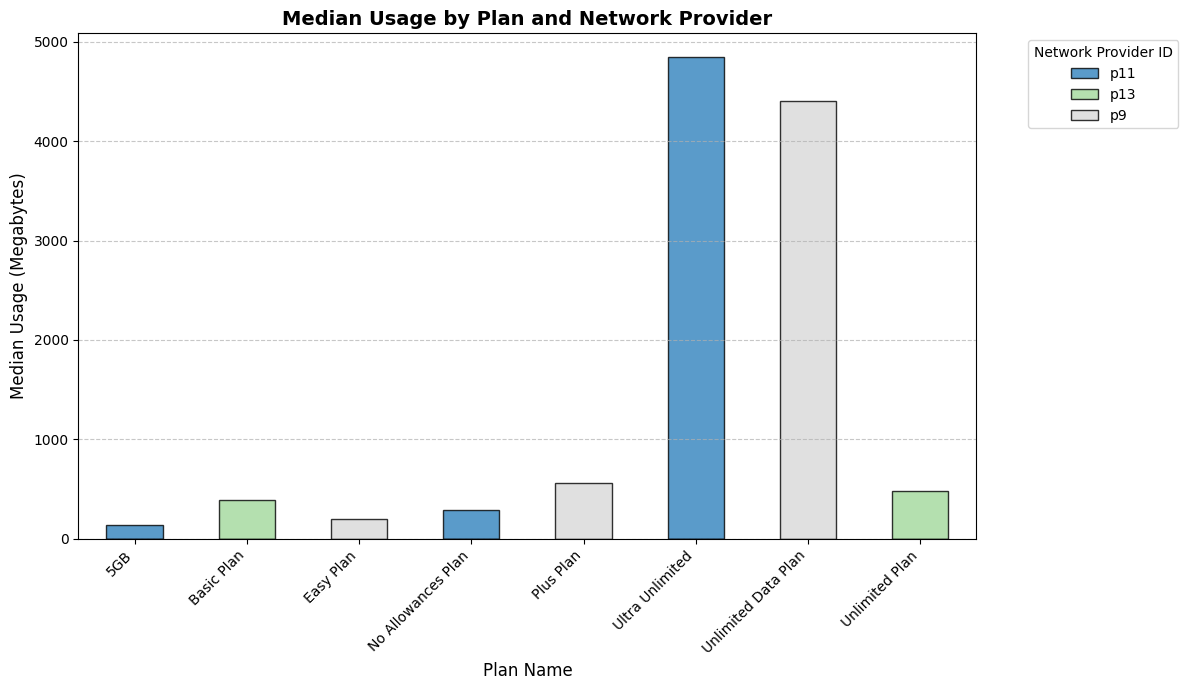

In [36]:
# Sort values by median_avg for better visualization
result_sorted = summary.sort_values('median_avg', ascending=False)

plan_totals = summary.groupby('plan_name')['median_avg'].sum().sort_values(ascending=False)

# Pivot data to get network_provider_id as columns (for stacked colors)
pivot_data = result_sorted.pivot(
    index='plan_name',
    columns='network_provider_id',
    values='median_avg'
).fillna(0)

# Create stacked bar chart
pivot_data.plot(
    kind='bar',
    stacked=True,
    figsize=(12, 7),
    colormap='tab20c',
    edgecolor='black',
    alpha=0.8
)

# Add labels and styling
plt.title('Median Usage by Plan and Network Provider', fontsize=14, weight='bold')
plt.xlabel('Plan Name', fontsize=12)
plt.ylabel('Median Usage (Megabytes)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Network Provider ID', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


### Answer Q2:
> The compsumption is noticeable higher with ultra unlimited and unlimited data plan.

> The network provider has no effect on the comsumption.

---
## Q3: Do subscriptions typically consume consistent amounts of data throughout their lifetime?

What is a good measure of consistency? 

A low std dev. lets google/chatgpt a coefficient or other measure to use.

Found : 

Coefficient of variation  = std.dev / average

perfect! lets use it.

In [37]:
%%sql

WITH 

valid_subscriptions AS (

  SELECT 
    subscription_id,
    MAX(reporting_date) as latest_report,
    MAX(subscription_period_end) as last_period_end_date
  FROM
    usage_data
  GROUP BY 
    subscription_id
  HAVING
     MAX(reporting_date) >= MAX(subscription_period_end) 
),

subscription_usage AS (
  
  SELECT 
    a.project_id__hashed,
    a.subscription_id,
    COUNT(a.subscription_period_number) AS count_periods,
    SUM(a.cumulative_data_usage_megabyte) AS sum_data_usage,
    SUM(a.cumulative_data_usage_megabyte) / COUNT(a.subscription_period_number) as avg_usage,
    STDDEV(a.cumulative_data_usage_megabyte) / AVG(a.cumulative_data_usage_megabyte) as coef_var_usage,

  FROM 
    usage_data as a
  INNER JOIN 
    valid_subscriptions as b
    on a.subscription_id = b.subscription_id
  
    
  GROUP BY 1,2
  HAVING sum_data_usage > 0 
  
)
  
  
SELECT 
  
 median(coef_var_usage) as median_coef_var, 
 min(coef_var_usage) as min_coef_var,
 max(coef_var_usage) as max_coef_var,
 PERCENTILE_CONT(0.25) WITHIN GROUP( ORDER BY coef_var_usage) as p25_coef_var,
 PERCENTILE_CONT(0.50) WITHIN GROUP( ORDER BY coef_var_usage) as p50_coef_var,
 PERCENTILE_CONT(0.75) WITHIN GROUP( ORDER BY coef_var_usage) as p75_coef_var,
 PERCENTILE_CONT(0.80) WITHIN GROUP( ORDER BY coef_var_usage) as p80_coef_var,
 PERCENTILE_CONT(0.95) WITHIN GROUP( ORDER BY coef_var_usage) as p95_coef_var,
 COUNT(subscription_id) as count_subscriptions, 

FROM
  subscription_usage



,median_coef_var,min_coef_var,max_coef_var,p25_coef_var,p50_coef_var,p75_coef_var,p80_coef_var,p95_coef_var,count_subscriptions
0,0.98315,0.0,3.605551,0.635864,0.98315,1.414214,1.414214,2.232727,1695


In [38]:
valid_subscriptions = df.groupby('subscription_id').agg(
    latest_report=('reporting_date', 'max'),
    last_period_end_date=('subscription_period_end', 'max')
).reset_index()


valid_subscriptions = valid_subscriptions[
    valid_subscriptions['latest_report'] >= valid_subscriptions['last_period_end_date']
]

merged_df = df.merge(
    valid_subscriptions[['subscription_id']], 
    on='subscription_id', 
    how='inner'
)

subscription_usage = merged_df.groupby(['project_id__hashed', 'subscription_id']).agg(
    count_periods=('subscription_period_number', 'count'),
    sum_data_usage=('cumulative_data_usage_megabyte', 'sum'),
    avg_usage=('cumulative_data_usage_megabyte', 'mean'),
    coef_var_usage=('cumulative_data_usage_megabyte', lambda x: x.std() / x.mean() if x.mean() != 0 else 0)
).reset_index()

subscription_usage = subscription_usage[subscription_usage['sum_data_usage'] > 0]

result = {
    'median_coef_var': subscription_usage['coef_var_usage'].median(),
    'min_coef_var': subscription_usage['coef_var_usage'].min(),
    'max_coef_var': subscription_usage['coef_var_usage'].max(),
    'p25_coef_var': subscription_usage['coef_var_usage'].quantile(0.25),
    'p50_coef_var': subscription_usage['coef_var_usage'].quantile(0.50),
    'p75_coef_var': subscription_usage['coef_var_usage'].quantile(0.75),
    'p80_coef_var': subscription_usage['coef_var_usage'].quantile(0.80),
    'p95_coef_var': subscription_usage['coef_var_usage'].quantile(0.95),
    'count_subscriptions': subscription_usage['subscription_id'].nunique()
}

result_df = pd.DataFrame([result])
result_df

,median_coef_var,min_coef_var,max_coef_var,p25_coef_var,p50_coef_var,p75_coef_var,p80_coef_var,p95_coef_var,count_subscriptions
0,0.98315,0.0,3.605551,0.635864,0.98315,1.414214,1.414214,2.232727,1695



---
---
---
# Sandbox

In [ ]:
%%sql

# example of a subscription with multiple plans
select 
* 
from projects
limit 5;

,project_id__hashed,project_type,organization_name,device_type
0,dace2786aee7632e61757b320a6fe5bff37a2e742fe558...,API,People Mobile,Phones
1,82728d5d3cf7f35b58bc318399c2c5caf7eeadcc37f359...,Connect,ACME Phone,Phones
2,2aeca1a6c1ecf52b28b7f7646b6fb90563a417ee3e5dc3...,Connect,SmartDevices Inc.,Wearables


In [ ]:
%%sql

# example of a subscription with multiple plans
select 
* 
from plan_events
limit 3;

,plan_id,project_id__hashed,plan_created_at,event_type,event_timestamp,plan_name,network_provider_id,price_currency,plan_price_amount_local,data_allowance_mb,is_unlimited_data,voice_allowance_seconds,is_unlimited_voice,sms_allowance,is_unlimited_sms,validity_value,validity_unit,_valid_from,_valid_to,_is_current_state
0,pln_b2a155624e05108d1a5b6b90f567,82728d5d3cf7f35b58bc318399c2c5caf7eeadcc37f359...,2023-12-29 18:43:12,plan.updated,2023-12-29 18:44:37.573698,Unlimited Data Plan,p4,USD,70.0,NaN,True,NaN,True,NaN,True,30,day,2023-12-29 18:44:37.573698,2023-12-29 18:44:37.846803,False
1,pln_b2a155624e05108d1a5b6b90f567,82728d5d3cf7f35b58bc318399c2c5caf7eeadcc37f359...,2023-12-29 18:43:12,plan.archived,2024-01-21 15:48:13.444971,Unlimited Data Plan,p4,USD,70.0,NaN,True,NaN,True,NaN,True,30,day,2024-01-21 15:48:13.444971,NaT,True
2,pln_b2a155624e05108d1a5b6b90f567,82728d5d3cf7f35b58bc318399c2c5caf7eeadcc37f359...,2023-12-29 18:43:12,plan.updated,2024-01-21 15:48:12.953812,Unlimited Data Plan,p4,USD,70.0,NaN,True,NaN,True,NaN,True,30,day,2024-01-21 15:48:12.953812,2024-01-21 15:48:13.444971,False


In [ ]:
%%sql

# example of a subscription with multiple plans
select 
* 
from usage_data
limit 5

,subscription_id,project_id__hashed,plan_id,reporting_date,subscription_period_start,subscription_period_end,subscription_period_number,cumulative_data_usage_megabyte,cumulative_voice_usage_minutes,cumulative_sms_usage,number_of_addons_activated
0,sub_b97107a1c7ef89cf28a7e83ee850,82728d5d3cf7f35b58bc318399c2c5caf7eeadcc37f359...,pln_0a3b55b9abb575b023c07e617b49,2024-02-07,2024-02-04,2024-02-07,1,0.000000,0.0,0.0,0
1,sub_2353ef9e8bf55916b97ceb30194c,82728d5d3cf7f35b58bc318399c2c5caf7eeadcc37f359...,pln_0a3b55b9abb575b023c07e617b49,2024-02-08,2024-01-25,2024-02-08,1,56.660992,1.0,1.0,0
2,sub_5d5605c8cf0b46116a42cedb9561,82728d5d3cf7f35b58bc318399c2c5caf7eeadcc37f359...,pln_1d3f49d61a672755efc1865c4d9a,2024-02-08,2024-01-25,2024-02-08,1,160.659456,0.0,1.0,0
3,sub_8e114d3a638d12ca1526a3fbedd6,82728d5d3cf7f35b58bc318399c2c5caf7eeadcc37f359...,pln_0a3b55b9abb575b023c07e617b49,2024-02-08,2024-01-28,2024-02-08,1,156.870656,93.0,198.0,0
4,sub_16059484727214a6b903fa16d0fe,82728d5d3cf7f35b58bc318399c2c5caf7eeadcc37f359...,pln_0a3b55b9abb575b023c07e617b49,2024-02-10,2024-02-09,2024-02-10,1,0.000000,0.0,0.0,0


In [ ]:
%%sql

# example of a subscription with multiple plans
select 
* 
from plan_events
limit 3

,plan_id,project_id__hashed,plan_created_at,event_type,event_timestamp,plan_name,network_provider_id,price_currency,plan_price_amount_local,data_allowance_mb,is_unlimited_data,voice_allowance_seconds,is_unlimited_voice,sms_allowance,is_unlimited_sms,validity_value,validity_unit,_valid_from,_valid_to,_is_current_state
0,pln_b2a155624e05108d1a5b6b90f567,82728d5d3cf7f35b58bc318399c2c5caf7eeadcc37f359...,2023-12-29 18:43:12,plan.updated,2023-12-29 18:44:37.573698,Unlimited Data Plan,p4,USD,70.0,NaN,True,NaN,True,NaN,True,30,day,2023-12-29 18:44:37.573698,2023-12-29 18:44:37.846803,False
1,pln_b2a155624e05108d1a5b6b90f567,82728d5d3cf7f35b58bc318399c2c5caf7eeadcc37f359...,2023-12-29 18:43:12,plan.archived,2024-01-21 15:48:13.444971,Unlimited Data Plan,p4,USD,70.0,NaN,True,NaN,True,NaN,True,30,day,2024-01-21 15:48:13.444971,NaT,True
2,pln_b2a155624e05108d1a5b6b90f567,82728d5d3cf7f35b58bc318399c2c5caf7eeadcc37f359...,2023-12-29 18:43:12,plan.updated,2024-01-21 15:48:12.953812,Unlimited Data Plan,p4,USD,70.0,NaN,True,NaN,True,NaN,True,30,day,2024-01-21 15:48:12.953812,2024-01-21 15:48:13.444971,False


In [ ]:


%%sql

# example of a subscription with multiple plans
select 

*

from usage_data
limit 2

,subscription_id,project_id__hashed,plan_id,reporting_date,subscription_period_start,subscription_period_end,subscription_period_number,cumulative_data_usage_megabyte,cumulative_voice_usage_minutes,cumulative_sms_usage,number_of_addons_activated
0,sub_b97107a1c7ef89cf28a7e83ee850,82728d5d3cf7f35b58bc318399c2c5caf7eeadcc37f359...,pln_0a3b55b9abb575b023c07e617b49,2024-02-07,2024-02-04,2024-02-07,1,0.000000,0.0,0.0,0
1,sub_2353ef9e8bf55916b97ceb30194c,82728d5d3cf7f35b58bc318399c2c5caf7eeadcc37f359...,pln_0a3b55b9abb575b023c07e617b49,2024-02-08,2024-01-25,2024-02-08,1,56.660992,1.0,1.0,0


In [ ]:

%%sql

# example of a subscription with multiple plans
select 
subscription_id, count(distinct plan_id) as countplans
from usage_data
group by 1
order by 2 desc

,subscription_id,countplans
0,sub_901abaf7b1c334d7af1fea3605a5,3
1,sub_b51ba8d0e300a9efa087369f134e,3
2,sub_1171c22ec8ebf155b417f849a299,3
3,sub_43b98ea5cf200d71c9f6f04f7363,3
4,sub_7527d51ab0c81f907d51aa3f5ee2,3
...,...,...
8452,sub_a89caf392b527d2367f743fafdea,1
8453,sub_feba792d260534cddd841588ea07,1
8454,sub_f524203c604396197f45bd4fbd1e,1
8455,sub_603da2fd4d2abe039d15d7498b48,1


In [ ]:

%%sql

# example of a subscription with multiple plans
select 
plan_id, count(distinct plan_name) as countplans
from plan
group by 1
order by 2 desc
limit 5

,plan_id,countplans
0,pln_9127a74e8d609bcaf5cb6572ba68,3
1,pln_53c4cf73a93fef35a57d35ff0167,2
2,pln_d33b29636fd869a3def08d0fb54f,1
3,pln_d2d79ec326a0f13ae7f5a04d874b,1
4,pln_a6052925ca2848a5356fc9d76cf4,1


In [ ]:


%%sql

# example of a subscription with multiple plans
select 
plan_name, count(distinct plan_id) as countplans
from plan
group by 1
order by 2 desc
limit 5

,plan_name,countplans
0,Unlimited Plan,8
1,Ultra Unlimited,7
2,No Allowances Plan,5
3,5GB Plan,5
4,5GB,3


In [ ]:
a = "plan_name	network_provider_id	is_unlimited_data	voice_allowance_seconds	is_unlimited_voice	sms_allowance	is_unlimited_sms".split("\t")
plan.groupby(a).size().reset_index()


,plan_name,network_provider_id,is_unlimited_data,voice_allowance_seconds,is_unlimited_voice,sms_allowance,is_unlimited_sms,0
0,No Allowances Plan,p11,False,0.0,False,0.0,False,31
1,SMS Only Plan,p11,False,0.0,False,0.0,False,4


In [ ]:
plan.validity_value.unique()

array([30,  1])

In [ ]:
plan.network_provider_id.unique()

array(['p4', 'p9', 'p13', 'p11'], dtype=object)

,plan_name,network_provider_id,is_unlimited_data,voice_allowance_seconds,is_unlimited_voice,sms_allowance,is_unlimited_sms,count
0,Ultra Unlimited,p11,True,NaN,True,NaN,True,33
1,No Allowances Plan,p11,False,0.0,False,0.0,False,31
2,Unlimited Plan,p11,True,NaN,True,NaN,True,30
3,5GB Plan,p11,False,NaN,True,NaN,True,27
4,5GB,p11,False,NaN,True,NaN,True,20
5,Unlimited Plan,p13,True,NaN,True,NaN,True,11
6,Unlimited Data Plan,p9,True,NaN,True,NaN,True,9
7,Plus Plan,p9,False,NaN,True,NaN,True,8
8,Easy Plan,p9,False,NaN,True,NaN,True,8
9,SMS Only Plan,p11,False,0.0,False,NaN,True,6
